In [1]:
import sys
from pathlib import Path

def find_project_root(markers=("src", "Data", "Notebooks")):
    current_path = Path.cwd().resolve()

    for path in [current_path] + list(current_path.parents):
        has_all_markers = all((path / marker).exists() for marker in markers)
        if has_all_markers:
            return path

    raise RuntimeError(f"Project root could not be found from: {current_path}")

project_root = find_project_root()
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import paths as P
import pandas as pd

In [2]:
analysis_file = P.decision_logs_cleaned_dir / "decision_logs_cleaned_with_ids.csv"
df = pd.read_csv(analysis_file)

print("Shape:", df.shape)
print("Unique runs:", df["run_id"].nunique())
print("Unique scenarios:", df["scenario_id"].nunique())
print("Unique choices:", df["choice_id"].nunique())
print()

display(
    df[[
        "run_id",
        "module_code",
        "decision_order",
        "scenario_id",
        "choice_id",
        "decisionLog_choice",
        "finalScores_budget",
        "completed_run",
        "ended_early"
    ]].head()
)

Shape: (2009, 24)
Unique runs: 136
Unique scenarios: 15
Unique choices: 45



,run_id,module_code,decision_order,scenario_id,choice_id,decisionLog_choice,finalScores_budget,completed_run,ended_early
0,run_1776087643609_b1186f57813e18,CT4010,1,F,F2,Negotiate While Recovering,276000,True,False
1,run_1776087643609_b1186f57813e18,CT4010,2,O,O2,Move to Third-Party Cloud,276000,True,False
2,run_1776087643609_b1186f57813e18,CT4010,3,J,J3,Phased Access Review,276000,True,False
3,run_1776087643609_b1186f57813e18,CT4010,4,B,B3,Apply Temporary Mitigations,276000,True,False
4,run_1776087643609_b1186f57813e18,CT4010,5,L,L2,Optional Training Modules,276000,True,False


In [3]:
# Basic structure summary
rows_by_module = df["module_code"].value_counts().rename_axis("module_code").reset_index(name="count")
rows_by_scenario = df["scenario_id"].value_counts().sort_index().rename_axis("scenario_id").reset_index(name="count")
rows_by_choice = df["choice_id"].value_counts().sort_index().rename_axis("choice_id").reset_index(name="count")

display(rows_by_module)
display(rows_by_scenario)
display(rows_by_choice)

,module_code,count
0,CT4010,1027
1,CT5056,654
2,CT6033,209
3,CT7074,119


,scenario_id,count
0,A,133
1,B,134
2,C,135
3,D,134
4,E,133
5,F,135
6,G,132
7,H,134
8,I,133
9,J,134


,choice_id,count
0,A1,95
1,A2,18
2,A3,20
3,B1,20
4,B2,25
5,B3,89
6,C1,86
7,C2,21
8,C3,28
9,D1,20


In [4]:
# Main scenario-choice summary table
scenario_choice_summary = (
    df.groupby(["scenario_id", "choice_id", "decisionLog_choice"])
      .size()
      .reset_index(name="count")
      .sort_values(["scenario_id", "choice_id"])
)

scenario_totals = (
    scenario_choice_summary.groupby("scenario_id")["count"]
    .transform("sum")
)

scenario_choice_summary["percentage"] = (
    scenario_choice_summary["count"] / scenario_totals * 100
).round(2)

display(scenario_choice_summary)

,scenario_id,choice_id,decisionLog_choice,count,percentage
0,A,A1,Immediate University-Wide Warning,95,71.43
1,A,A2,Investigate Before Communicating,18,13.53
2,A,A3,Block and Monitor Without Warning,20,15.04
3,B,B1,Take the System Offline Immediately,20,14.93
4,B,B2,Monitor and Delay Action,25,18.66
5,B,B3,Apply Temporary Mitigations,89,66.42
6,C,C1,Individual Accounts with MFA,86,63.70
7,C,C2,Temporary Sharing with a Deadline,21,15.56
8,C,C3,Enforce Individual Accounts,28,20.74
9,D,D1,Shut Down the Lab Immediately,20,14.93


In [5]:
run_level_summary = (
    df.groupby("run_id")
      .agg(
          module_code=("module_code", "first"),
          source_folder=("source_folder", "first"),
          n_decisions=("n_decisions", "first"),
          completed_run=("completed_run", "first"),
          ended_early=("ended_early", "first"),
          finalScores_budget=("finalScores_budget", "first"),
          finalScores_reputation=("finalScores_reputation", "first"),
          finalScores_security=("finalScores_security", "first"),
          finalScores_morale=("finalScores_morale", "first")
      )
      .reset_index()
)

display(run_level_summary)

,run_id,module_code,source_folder,n_decisions,completed_run,ended_early,finalScores_budget,finalScores_reputation,finalScores_security,finalScores_morale
0,run_1776072096396_637cd8aa2ffa98,CT4010,CT4010 Morning Decision Logs,15,True,False,282000,134,185,93
1,run_1776072124156_a8612277200c78,CT4010,CT4010 Morning Decision Logs,15,True,False,178000,91,158,80
2,run_1776072427752_42c612d92ff85,CT4010,CT4010 Morning Decision Logs,15,True,False,227000,156,200,120
3,run_1776072563293_c986b5b1022df,CT4010,CT4010 Morning Decision Logs,15,True,False,7000,56,96,89
4,run_1776072647167_c3bcf318bf4108,CT4010,CT4010 Morning Decision Logs,15,True,False,207000,87,130,86
...,...,...,...,...,...,...,...,...,...,...
131,run_1777023832521_693aeb5adbb388,CT6033,CT6033 Decision Logs,15,True,False,134000,0,28,34
132,run_1777023971675_c83d3f4ec1f498,CT6033,CT6033 Decision Logs,14,False,True,0,161,200,132
133,run_1777023985192_9a0326c4f50a9,CT6033,CT6033 Decision Logs,15,True,False,171000,165,200,133
134,run_1777023995053_d4799333441f48,CT6033,CT6033 Decision Logs,15,True,False,0,178,200,138


In [6]:
run_level_summary_file = P.decision_logs_tables_dir / "run_level_summary.csv"
run_level_summary.to_csv(run_level_summary_file, index=False)

print("Saved to:")
print(run_level_summary_file)

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\run_level_summary.csv


In [7]:
run_outcome_summary = (
    run_level_summary.groupby(["completed_run", "ended_early"])
    .agg(
        runs=("run_id", "count"),
        mean_n_decisions=("n_decisions", "mean"),
        mean_final_budget=("finalScores_budget", "mean"),
        mean_final_reputation=("finalScores_reputation", "mean"),
        mean_final_security=("finalScores_security", "mean"),
        mean_final_morale=("finalScores_morale", "mean")
    )
    .reset_index()
)

display(run_outcome_summary)

,completed_run,ended_early,runs,mean_n_decisions,mean_final_budget,mean_final_reputation,mean_final_security,mean_final_morale
0,False,True,11,12.181818,0.0,122.545455,179.818182,93.909091
1,True,False,125,15.000000,125920.0,137.744000,183.680000,110.256000


In [8]:
run_outcome_summary_file = P.decision_logs_tables_dir / "run_outcome_summary.csv"
run_outcome_summary.to_csv(run_outcome_summary_file, index=False)

print("Saved to:")
print(run_outcome_summary_file)

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\run_outcome_summary.csv


In [9]:
top_choice_by_scenario = (
    scenario_choice_summary
    .sort_values(["scenario_id", "count"], ascending=[True, False])
    .groupby("scenario_id")
    .head(1)
    .reset_index(drop=True)
)

display(top_choice_by_scenario)

,scenario_id,choice_id,decisionLog_choice,count,percentage
0,A,A1,Immediate University-Wide Warning,95,71.43
1,B,B3,Apply Temporary Mitigations,89,66.42
2,C,C1,Individual Accounts with MFA,86,63.70
3,D,D2,Isolate Affected Machines,106,79.10
4,E,E3,Supportive Manager-Led Check-In,70,52.63
5,F,F3,Refuse Payment and Restore from Backups,86,63.70
6,G,G1,Secure Remote Work Upgrade,68,51.52
7,H,H2,Full Security Assessment Before Approval,84,62.69
8,I,I3,Segment and Harden the Server,87,65.41
9,J,J1,Restrict Access Strictly,79,58.96


In [10]:
top_choice_by_scenario_file = P.decision_logs_tables_dir / "top_choice_by_scenario.csv"
top_choice_by_scenario.to_csv(top_choice_by_scenario_file, index=False)

print("Saved to:")
print(top_choice_by_scenario_file)

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\top_choice_by_scenario.csv


In [11]:
# Across each scenario, what was the average effect of the decisions students actually selected?
scenario_selected_effects = (
    df.groupby("scenario_id")
      .agg(
          decisions=("run_id", "count"),
          mean_budget_effect=("decisionLog_effects_budget", "mean"),
          mean_reputation_effect=("decisionLog_effects_reputation", "mean"),
          mean_security_effect=("decisionLog_effects_security", "mean"),
          mean_morale_effect=("decisionLog_effects_morale", "mean")
      )
      .reset_index()
)

display(scenario_selected_effects)

,scenario_id,decisions,mean_budget_effect,mean_reputation_effect,mean_security_effect,mean_morale_effect
0,A,133,-16917.293233,4.526316,6.766917,1.744361
1,B,134,-36716.417910,0.335821,5.940299,-1.149254
2,C,135,-27688.888889,5.614815,12.059259,0.718519
3,D,134,1179.104478,2.917910,9.552239,0.156716
4,E,133,-17909.774436,-0.270677,3.879699,0.533835
5,F,135,-95851.851852,0.088889,9.451852,-0.503704
6,G,132,-35272.727273,1.939394,3.818182,1.181818
7,H,134,-18179.104478,0.731343,4.701493,-1.044776
8,I,133,-23571.428571,3.556391,9.263158,1.496241
9,J,134,-16559.701493,3.985075,9.283582,-0.425373


In [12]:
scenario_selected_effects_file = P.decision_logs_tables_dir / "scenario_selected_effects.csv"
scenario_selected_effects.to_csv(scenario_selected_effects_file, index=False)

print("Saved to:")
print(scenario_selected_effects_file)

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\tables\scenario_selected_effects.csv


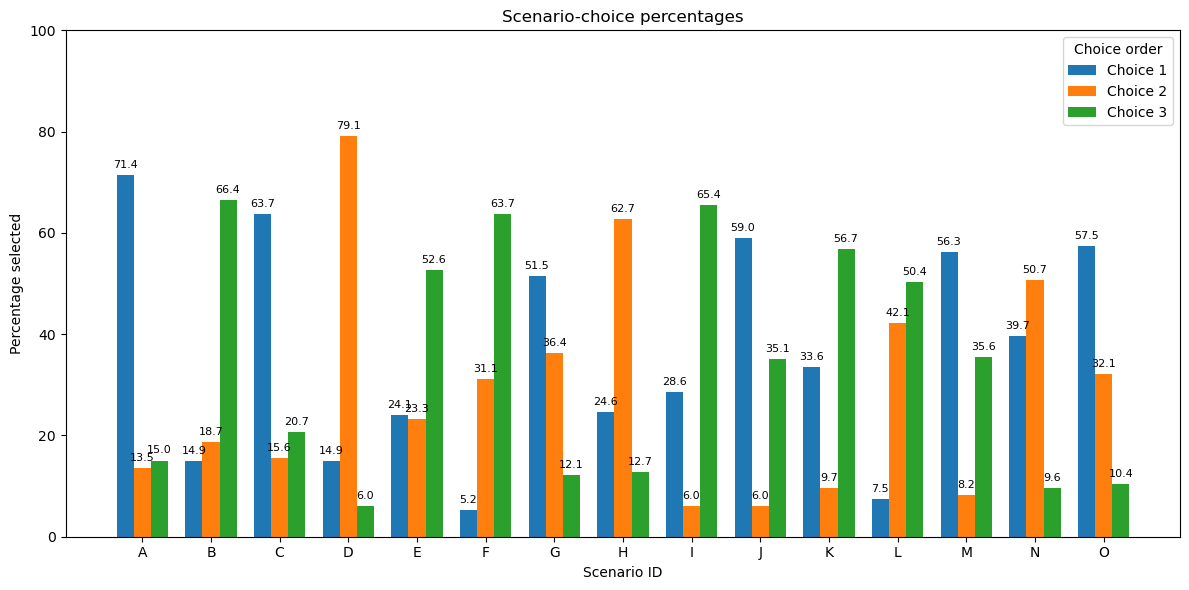

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\scenario_choice_percentages.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# create choice number from choice_id (A1 -> 1, A2 -> 2, etc.)
scenario_choice_plot = scenario_choice_summary.copy()
scenario_choice_plot["choice_number"] = scenario_choice_plot["choice_id"].str[-1]

# pivot for plotting
plot_df = scenario_choice_plot.pivot(
    index="scenario_id",
    columns="choice_number",
    values="percentage"
).fillna(0)

plot_df = plot_df[["1", "2", "3"]]

x = np.arange(len(plot_df.index))
width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width, plot_df["1"], width, label="Choice 1")
bars2 = plt.bar(x,         plot_df["2"], width, label="Choice 2")
bars3 = plt.bar(x + width, plot_df["3"], width, label="Choice 3")

plt.title("Scenario-choice percentages")
plt.xlabel("Scenario ID")
plt.ylabel("Percentage selected")
plt.xticks(x, plot_df.index)
plt.ylim(0, 100)
plt.legend(title="Choice order")

# optional: add percentage labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# save figure
scenario_choice_fig_file = P.decision_logs_figures_dir / "scenario_choice_percentages.png"
plt.savefig(scenario_choice_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(scenario_choice_fig_file)

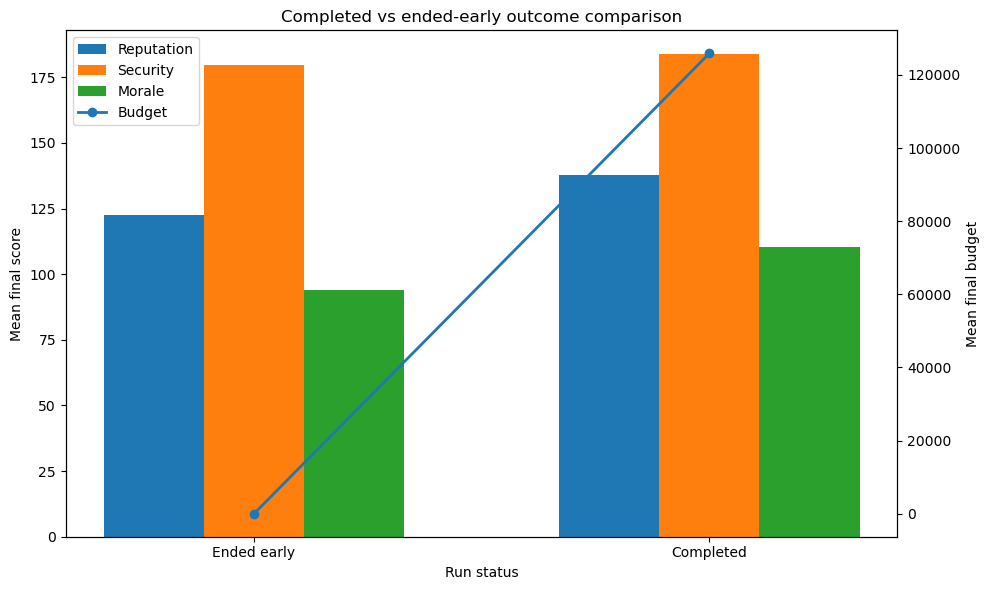

Saved to:
F:\scenario-based cyber security management simulation\ISMSimulationGame\ISMSimulationGame\Analysis\Outputs\Decision_Logs\figures\completed_vs_ended_early_outcomes.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# make cleaner labels
plot_df = run_outcome_summary.copy()
plot_df["run_status"] = np.where(
    plot_df["completed_run"],
    "Completed",
    "Ended early"
)

x = np.arange(len(plot_df))
width = 0.22

fig, ax1 = plt.subplots(figsize=(10, 6))

# bars for reputation, security, morale
ax1.bar(x - width, plot_df["mean_final_reputation"], width, label="Reputation")
ax1.bar(x,         plot_df["mean_final_security"],   width, label="Security")
ax1.bar(x + width, plot_df["mean_final_morale"],     width, label="Morale")

ax1.set_xlabel("Run status")
ax1.set_ylabel("Mean final score")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["run_status"])
ax1.set_title("Completed vs ended-early outcome comparison")

# second axis for budget
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["mean_final_budget"],
    marker="o",
    linewidth=2,
    label="Budget"
)
ax2.set_ylabel("Mean final budget")

# combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()

# save figure
run_outcome_fig_file = P.decision_logs_figures_dir / "completed_vs_ended_early_outcomes.png"
plt.savefig(run_outcome_fig_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:")
print(run_outcome_fig_file)